# Heteroscedastic LVGP BO — analysis (study_v2)

All plotting lives in the **`utils`** package (`utils/problem.py` = ground truth,
`utils/results.py` = the `StudyResults` class). Each `study.plot_*()` returns a `Figure`.

**DOE:** maximin LHS over [-2.5, 7.5] (outer-thirds), shared across categories. **Kernel:** `ml_gp_env`.


In [1]:
%matplotlib inline
import sys, os, importlib
sys.path.insert(0, os.getcwd())
import utils; importlib.reload(utils)
from utils import StudyResults

study = StudyResults.load('results')
study.summary()


1080 runs | 12 configs | n_rep=[3, 5, 10] | seeds=30 | ground-truth min = 0.465


---
## `is_ground_truth=` — the noisy-vs-true switch (read me)

BO only *observes* the **noisy sample-mean**, which can dip **below** the true minimum by
chance and also drives *which* design is called 'best'. Every ambiguous plot takes a single
boolean **`is_ground_truth=`**:

- **`is_ground_truth=False`** (noisy) → values / selection from the BO observations.
- **`is_ground_truth=True`** (ground truth) → the **noise-free `f_true`** at the design, and
  for selection plots the design is *ranked by `f_true`*.

Two flavors, both stamped in the title:
- **value plots** (`values = ...`): same reported design, objective shown noisy vs true —
  `simple_regret`, `objective_variance`, `pareto`, `nrep_sensitivity`, `summary_heatmaps`, `final_boxplots`.
- **selection plots** (`best = ranked by ...`): which design is 'best' —
  `x1_convergence`, `x1_distribution`, `incumbent_variance`, `best_designs`, `best_per_category`.

Plots with **no** noisy values are shown once: `progress`, `initial_doe`, `input_space`,
`level_histogram`, `runtime`, `single_run` (already overlays noisy points on true f).


---
## Plot styling, colour palettes & references

**Encoding** (so figures stay readable for colourblind readers *and* in grayscale print):
**colour + marker = acquisition family**, **linestyle = parameter** (low→solid, mid→dashed, high→dotted).
You learn it once (▲ = HAEI, dotted = largest parameter) and it holds across every plot.

**Switch the colour palette** (re-run the plot cells afterwards to see the change):

| name | notes |
|---|---|
| `okabe_ito` | colourblind-safe, **default** (Okabe & Ito / Wong) |
| `tol_bright`, `tol_muted`, `tol_vibrant` | colourblind-safe qualitative (Paul Tol) |
| `dark2` | ColorBrewer qualitative |
| `grayscale` | monochrome — relies on marker+linestyle to separate families |
| `custom` | your supplied 6-colour palette |

**References for the choices above:**
- Okabe & Ito (2008), *Color Universal Design (CUD)* — the default palette. <https://jfly.uni-koeln.de/color/>
- B. Wong (2011), "Color blindness," *Nature Methods* **8**:441.
- P. Tol (2021), *Colour Schemes*, SRON tech. note — the `tol_*` palettes.
- F. Crameri, G. Shephard & P. Heron (2020), "The misuse of colour in science communication," *Nature Communications* **11**:5444.
- P. Kovesi (2015), "Good Colour Maps: How to Design Them," arXiv:1509.03700.
- N. Rougier, M. Droettboom & P. Bourne (2014), "Ten Simple Rules for Better Figures," *PLoS Comput. Biol.* **10**(9):e1003833.
- Harrower & Brewer (2003), "ColorBrewer.org," *The Cartographic Journal* **40**(1):27–37.
- Sequential maps (`input_space`, `single_run`, heatmaps) use **viridis** (Smith & van der Walt, 2015) — perceptually uniform.


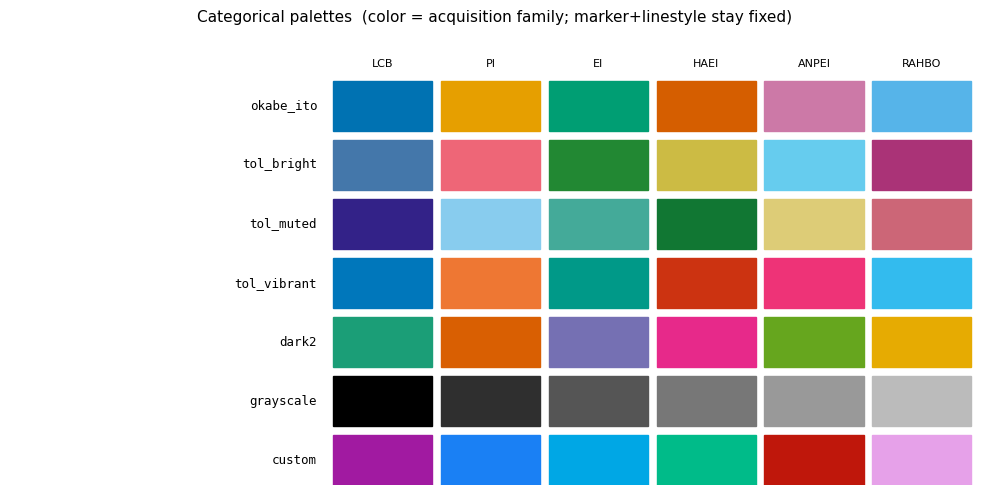

In [2]:
# preview all palettes (rows) across the 6 families (cols)
StudyResults.preview_palettes()


In [3]:
# pick a palette, then re-run the plot cells below to restyle everything
study.set_palette('custom')   # try: tol_bright | tol_muted | tol_vibrant | dark2 | grayscale


## 0. Overview


### 0a. Sweep progress (12 configs × 90)


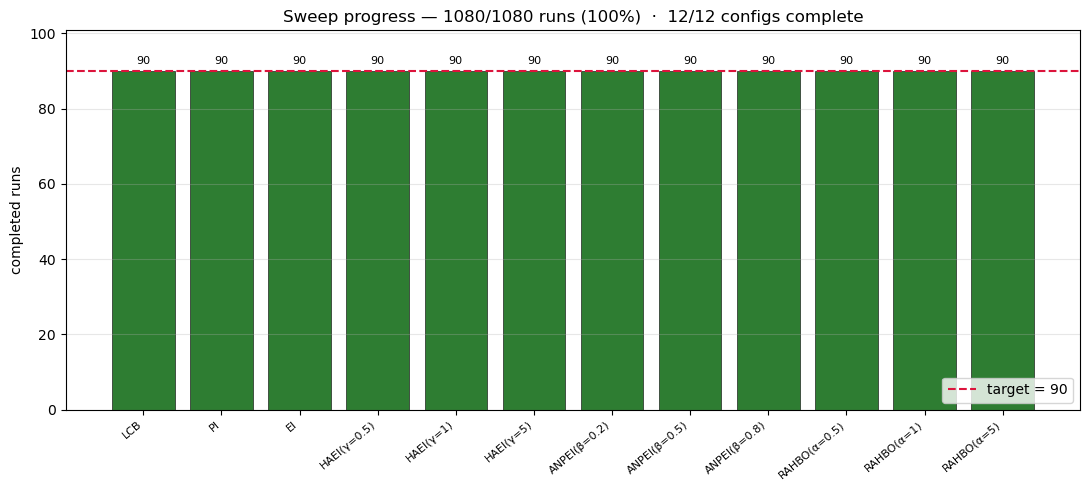

In [4]:
study.plot_progress()


### 0b. Initial DOE (starting designs, before BO) — *locations only*


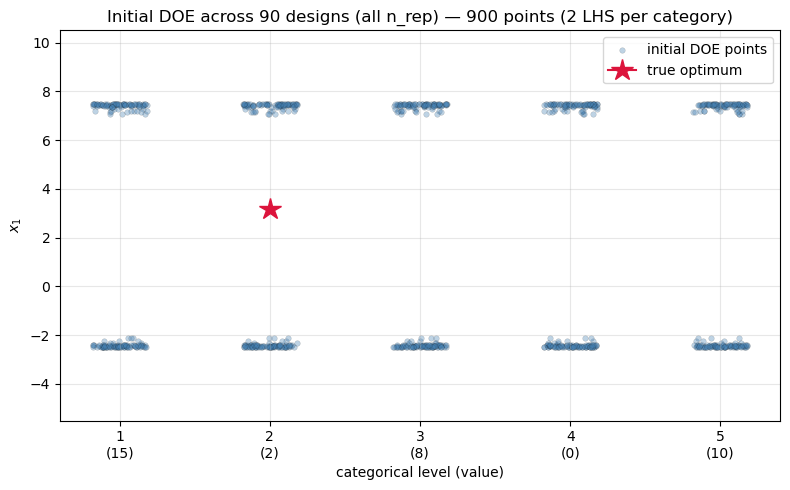

In [5]:
study.plot_initial_doe()


## 1. Convergence
`plot_convergence` is the noisy best sample-mean; `plot_convergence_true` is the true f at the recommendation.


### 1a. Best objective vs iteration — **NOISY** sample-mean


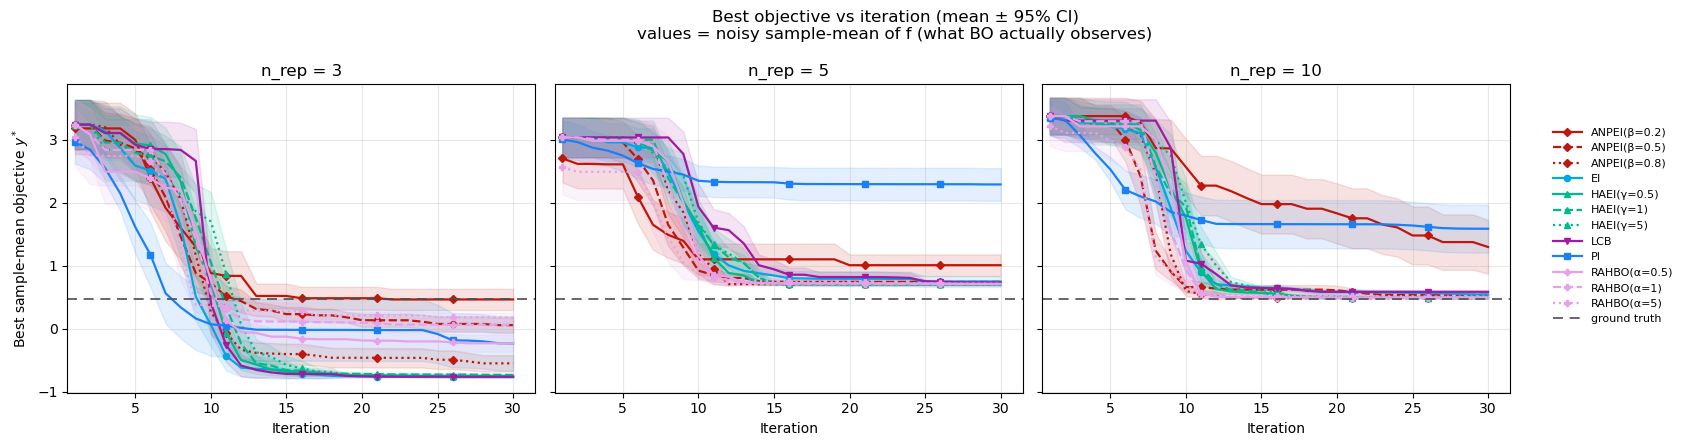

In [6]:
study.plot_convergence()


### 1b. Convergence vs ground truth — **TRUE** f at the recommended optimum
Early iterations spike (~30–40) and squash the convergence band on a linear axis.
`log=True` (recommended) de-squashes it and shows each curve approach the 0.465 floor;
`ymax=4` zooms into the convergence region; bare `plot_convergence_true()` is the raw linear view.


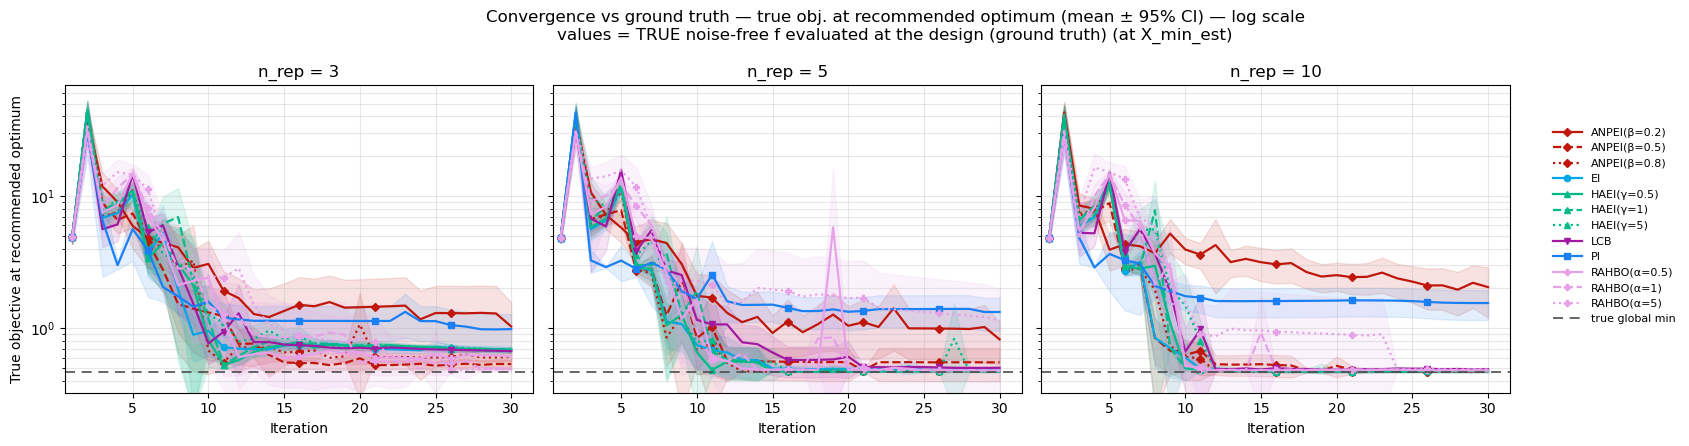

In [7]:
study.plot_convergence_true(log=True)     # recommended — log y-axis


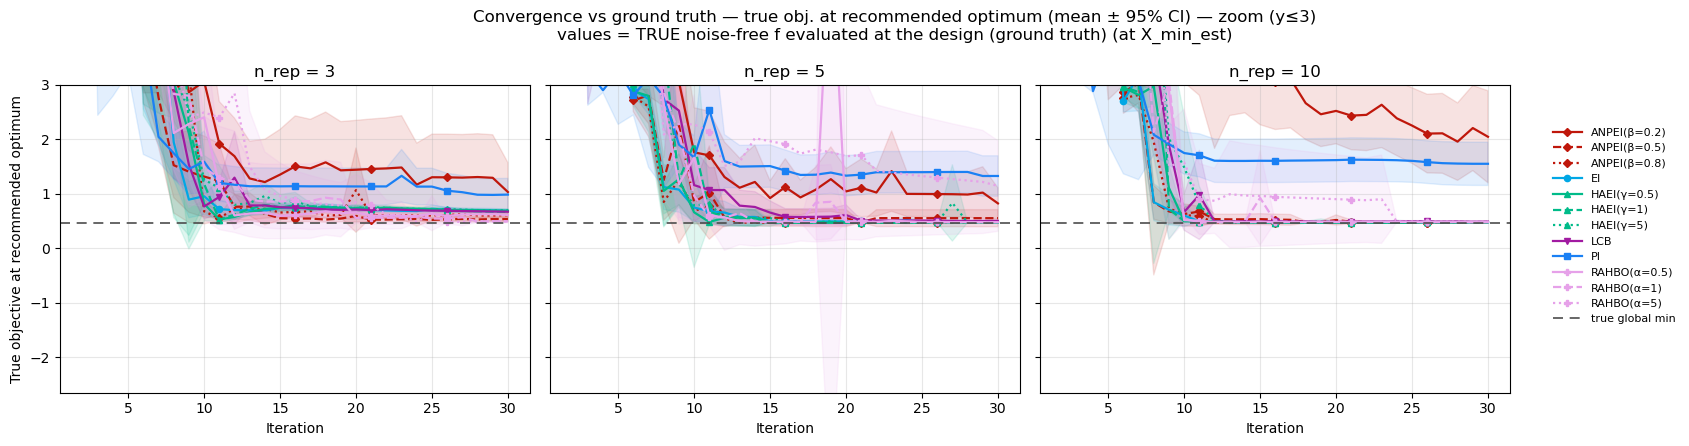

In [8]:
study.plot_convergence_true(ymax=3)       # zoom into the convergence band


### 1c. Simple regret vs iteration (log) — NOISY then TRUE


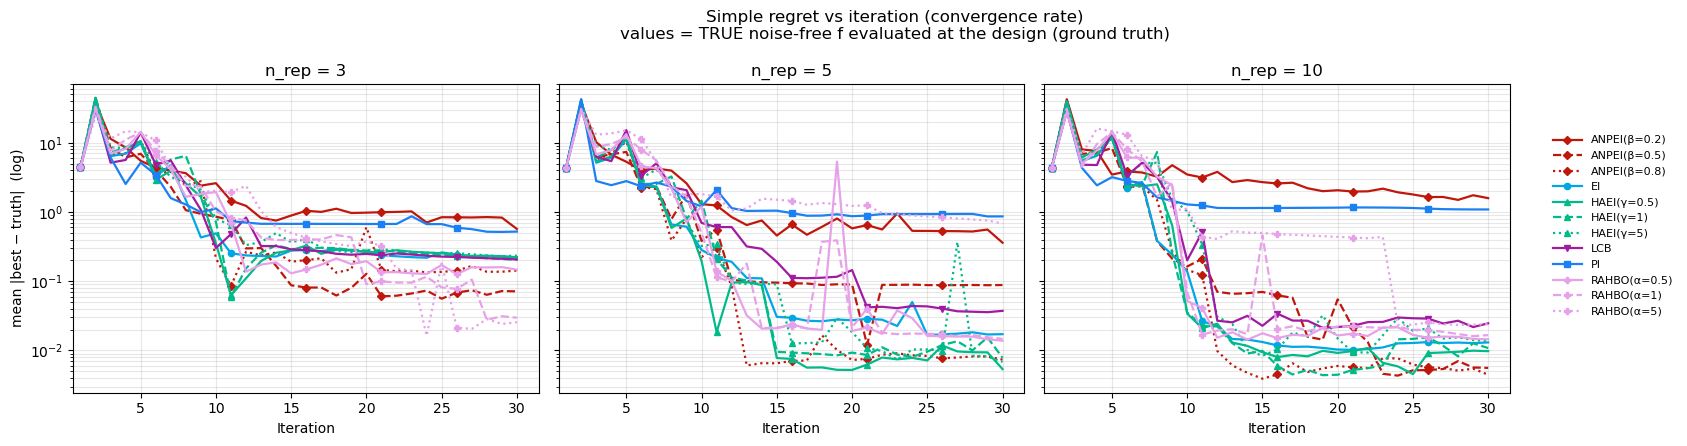

In [9]:
study.plot_simple_regret(is_ground_truth=True)   # eps= draws an ε-accuracy line


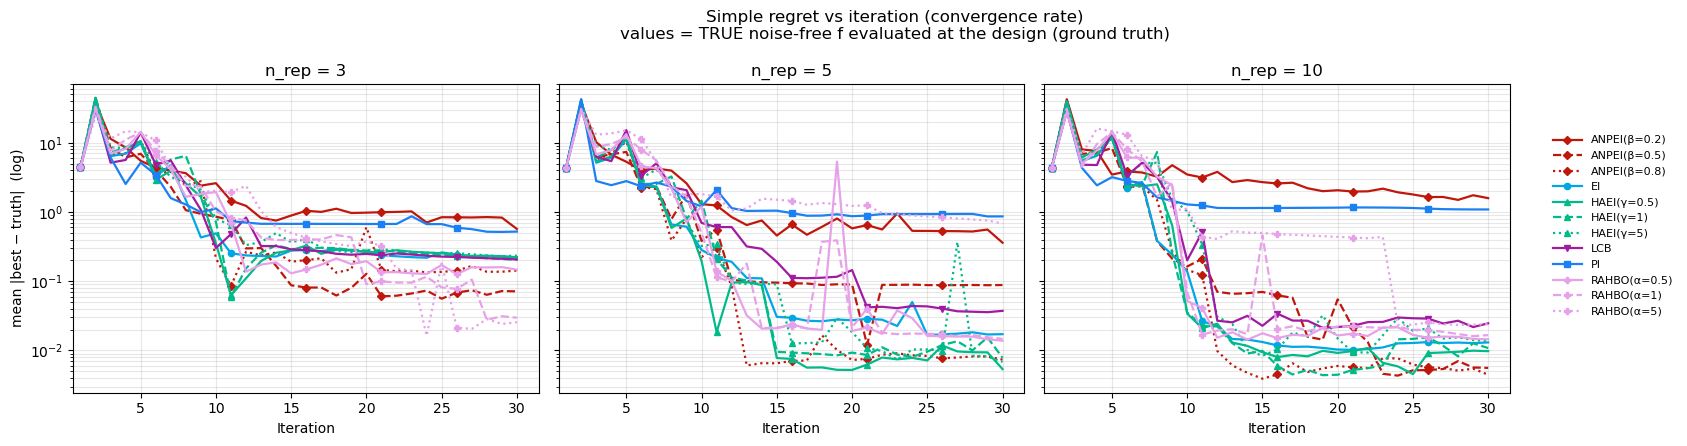

In [10]:
study.plot_simple_regret(is_ground_truth=True)


### 1c-table. Final simple-regret summary (per config × n_rep)

Condenses the curves above into one table. For each config the **final** simple regret
$|f-f^*|$ of the recommended optimum is summarised over the 30 seeds:

- **mean** — the value the log curve ends at (sensitive to a few bad seeds),
- **median** — robust centre; a large mean with a tiny median = a handful of failed seeds,
- **succ%** — % of seeds whose final recommendation is within `eps` of $f^*$,
- **it≤eps** — first iteration the *mean* regret reaches `eps` (convergence speed; `NaN` = never).

Conclusion-ready reads: (1) **n_rep** lifts succ% across the board; (2) at **n_rep=3** risk-aware
methods (RAHBO α=1/5) dominate; (3) **mean≫median** for ANPEI(β=0.2) / RAHBO(α=5) exposes the
tail-seed story; (4) **PI** never converges. Saved to `plots/analysis/simple_regret_table.xlsx`.


In [11]:
# build the table (TRUE regret, eps=0.1), write the styled Excel, and show it inline
reg_tbl = study.regret_table(is_ground_truth=True, eps=0.1,
                             excel_path='plots/analysis/simple_regret_table.xlsx')
reg_tbl.style.format(precision=4, na_rep='—') \
    .background_gradient(cmap='RdYlGn_r', subset=[(f'n_rep={nr}', m)
        for nr in study.n_reps for m in ('mean', 'median')])


wrote plots/analysis/simple_regret_table.xlsx


## 2. Best $x_1$ location vs ground truth
The $x_1$ value is exact; `is_ground_truth` flips whether the *best design* is picked by noisy mean or true f.


### 2a. $x_1$ convergence — NOISY-ranked then TRUE-ranked
By default off-category iterations are **masked** (only comparable category-2 $x_1$ is averaged),
so a curve may begin after iteration 1 if its best design starts in another category.
Set **`show_off_category=True`** to include every iteration's $x_1$ (continuous from iter 1,
but mixes categories). x-axis is shared and pinned to start at iteration 1.


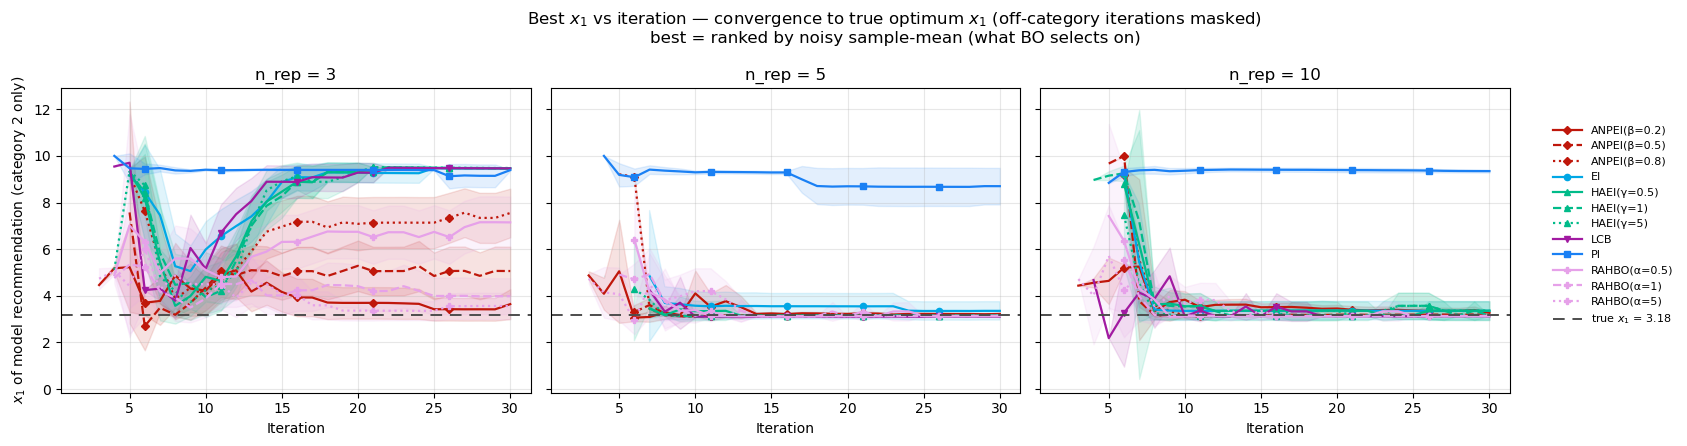

In [12]:
study.plot_x1_convergence(is_ground_truth=False)#, show_off_category=True)   # source='recommended' (model)


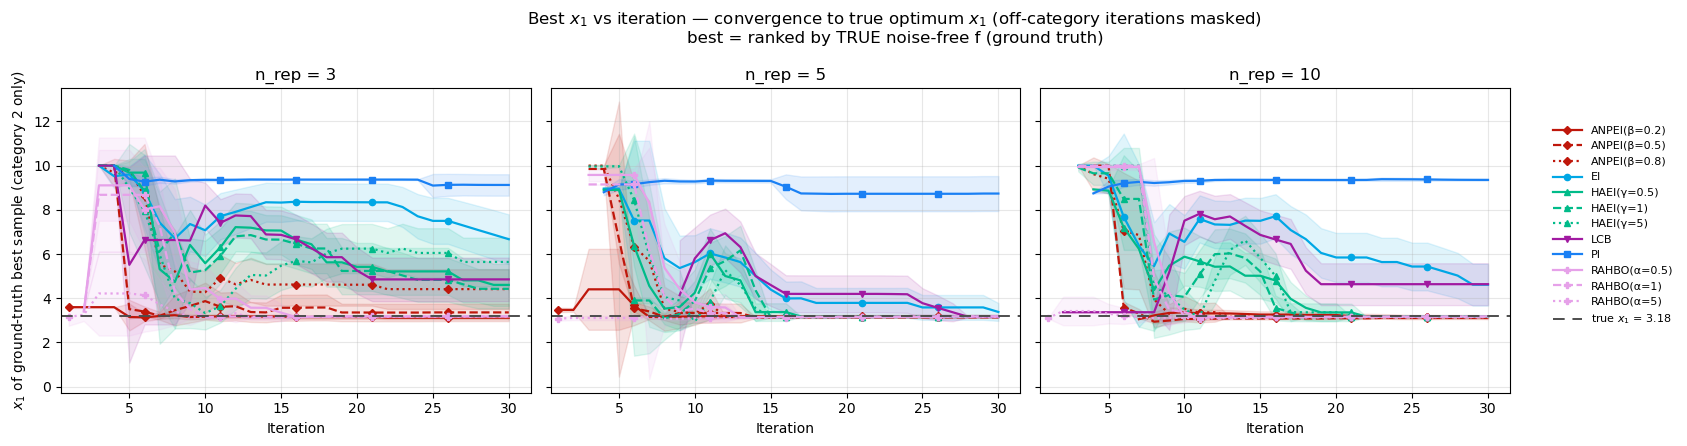

In [13]:
study.plot_x1_convergence(is_ground_truth=True)    # best ranked by true f


### 2b. Distribution of the final best $x_1$ — NOISY then TRUE
Uses the shared `final_design_table`, so only designs whose best is **actually in category 2**
enter the distribution; seeds whose best is in another category are counted under the label
(`show_off_category=True` overlays them as hollow diamonds).


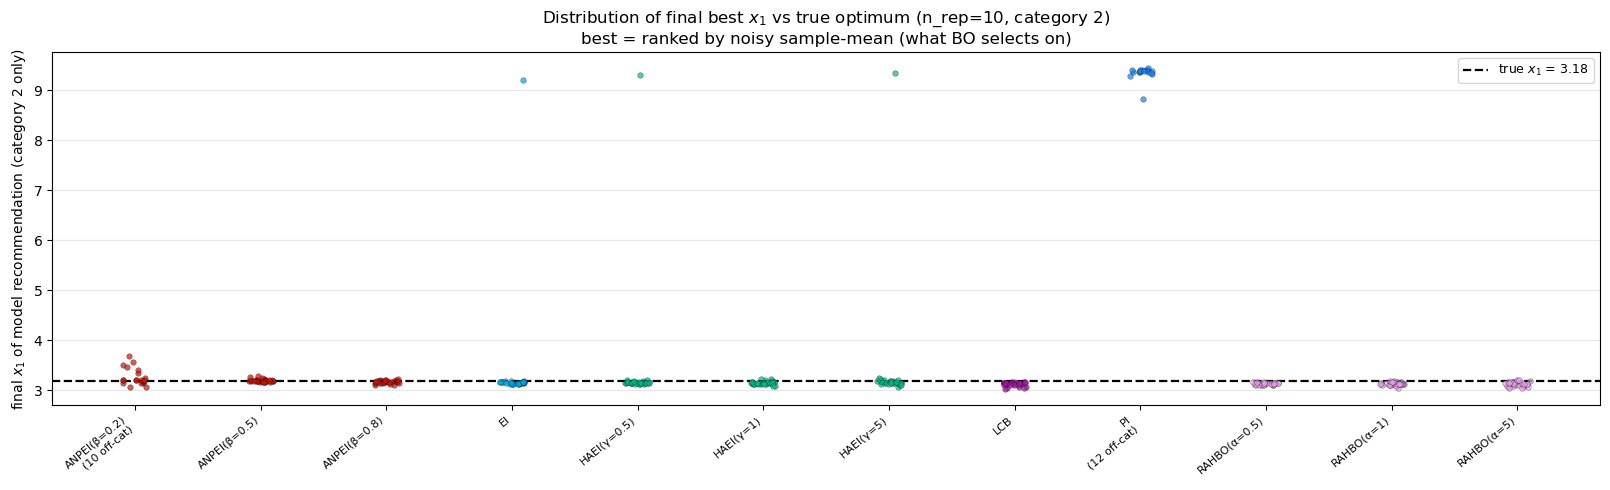

In [14]:
study.plot_x1_distribution(n_rep=10, show_violin=False, show_mean=False, is_ground_truth=False)


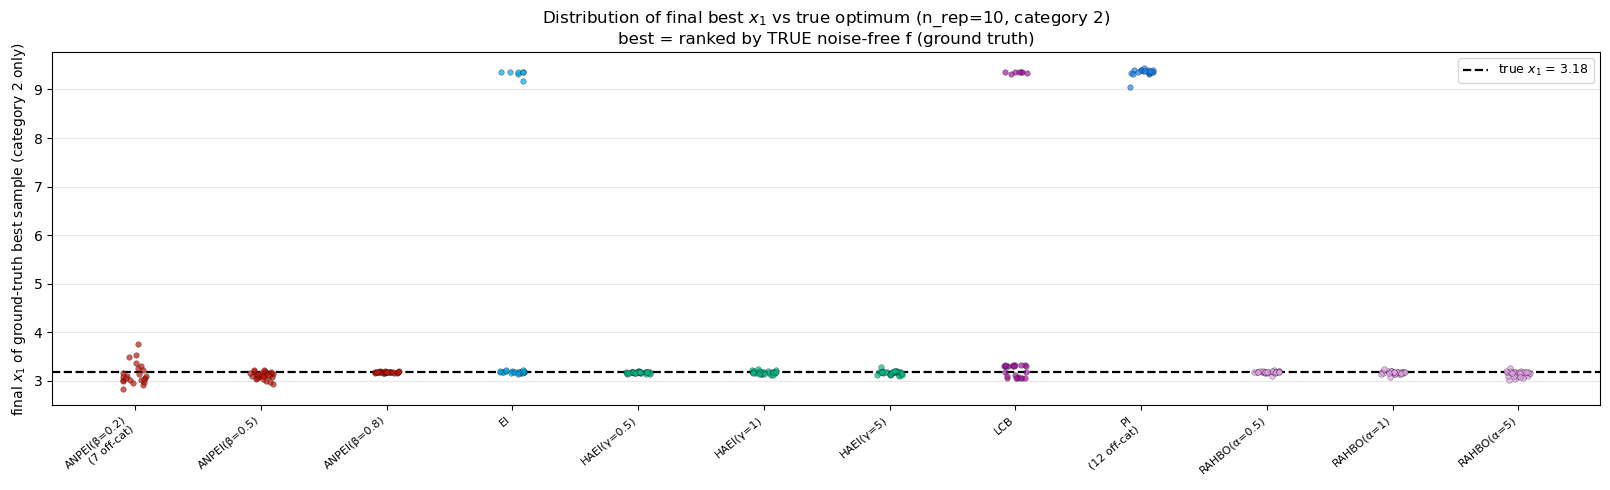

In [15]:
study.plot_x1_distribution(n_rep=10, show_violin=False, show_mean=False, is_ground_truth=True)


### 2c. Where the final design lands on the category-2 true function
Maps each seed's final design onto the optimal category (level 2) at its **true objective in
its own category**: filled dots = best is in category 2 (on the curve), open diamonds = best
is in another category (shown at its real objective). The dashed line is the true global min.
Knobs: `show_off_category=False` hides the other-category bests, plus `is_ground_truth=`,
`source=`, `n_rep=`, `basin_split=`, `ymax=`.


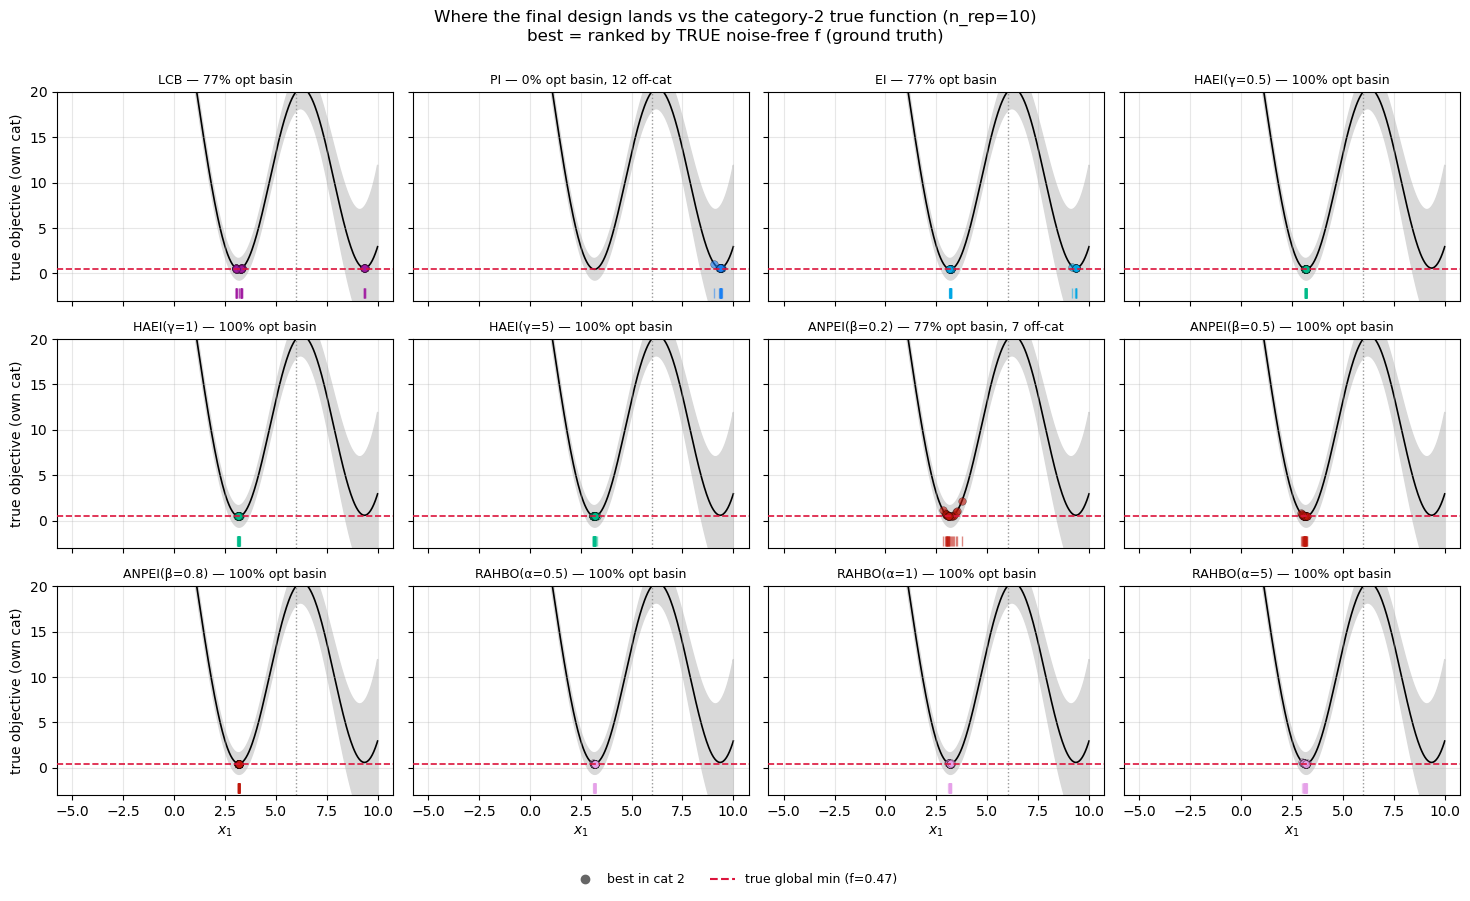

In [16]:
study.plot_x1_landing(n_rep=10, is_ground_truth=True, show_off_category=False, ymax=20)


## 3. Input space & categorical selection — *locations / counts only*


### 3a. Input-space sampling ($x_1$ vs level, colored by BO iteration)


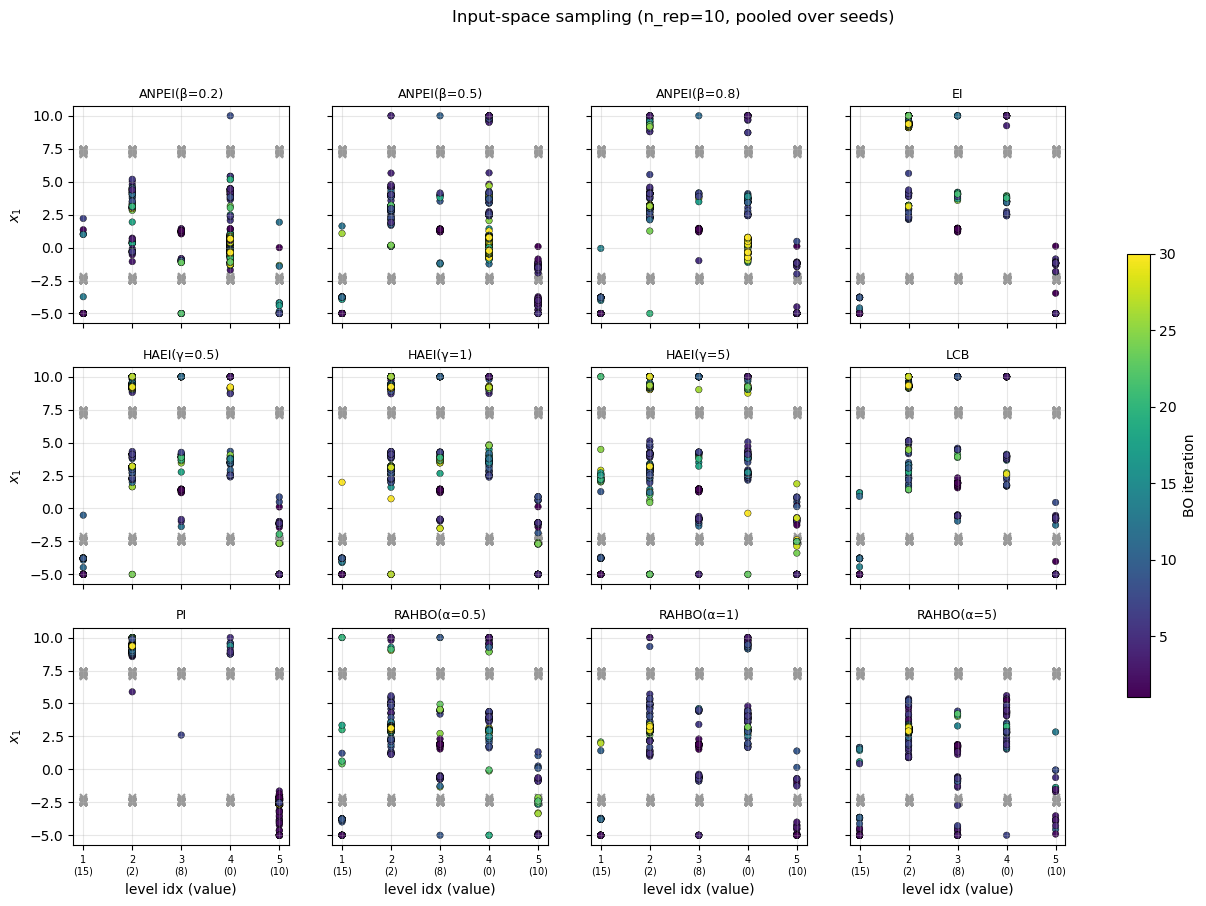

In [17]:
study.plot_input_space(n_rep=10)


### 3b. Categorical level selection frequency


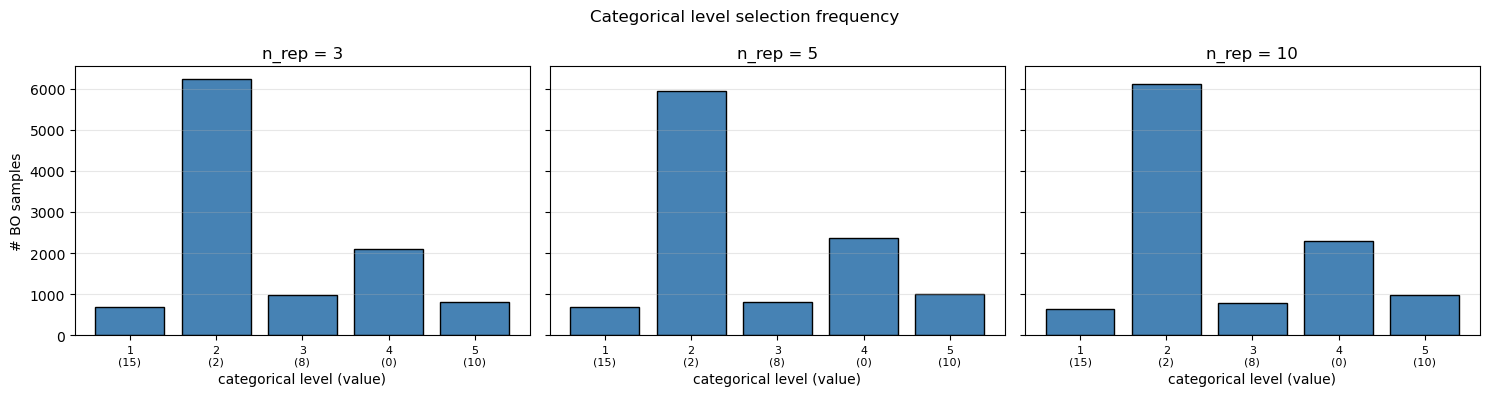

In [18]:
study.plot_level_histogram()


## 4. Objective vs aleatoric variance (risk)


### 4a. Objective–variance scatter — **NOISY** then **TRUE**


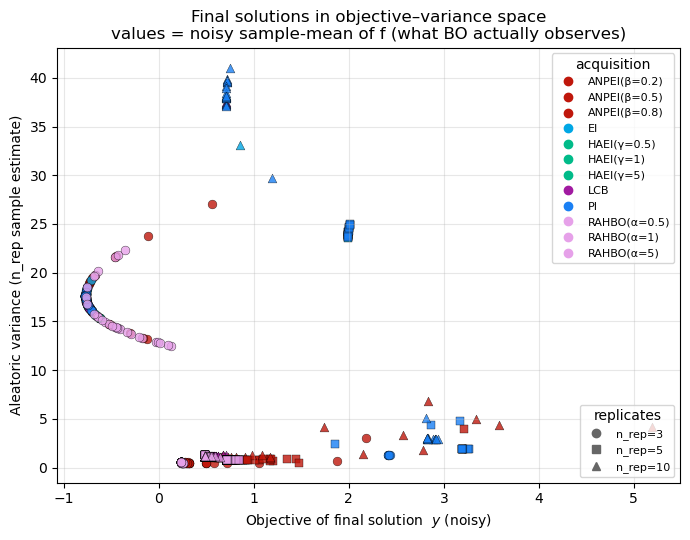

In [19]:
study.plot_objective_variance(is_ground_truth=False)


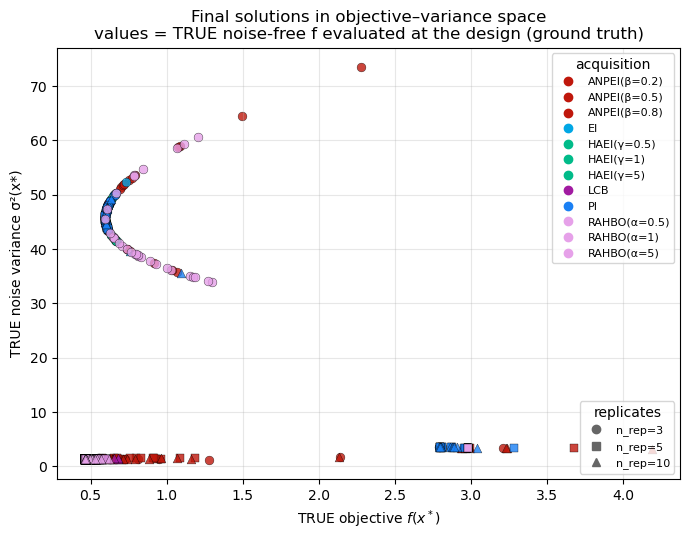

In [20]:
study.plot_objective_variance(is_ground_truth=True)


### 4b. Objective–variance Pareto front — **NOISY** then **TRUE**


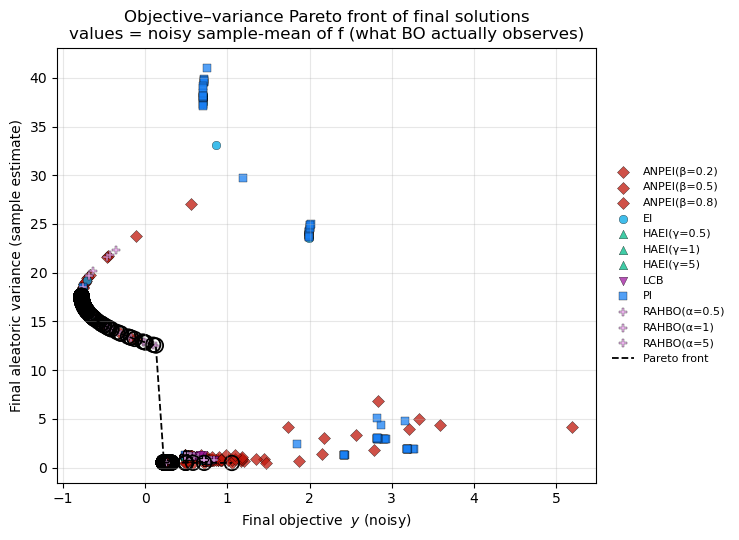

In [21]:
study.plot_pareto(is_ground_truth=False)


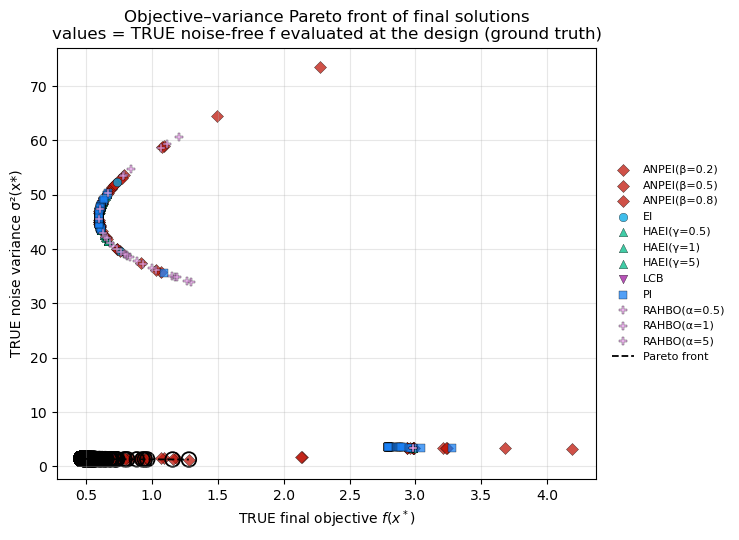

In [22]:
study.plot_pareto(is_ground_truth=True)


### 4c. Incumbent variance vs iteration — incumbent ranked NOISY then TRUE


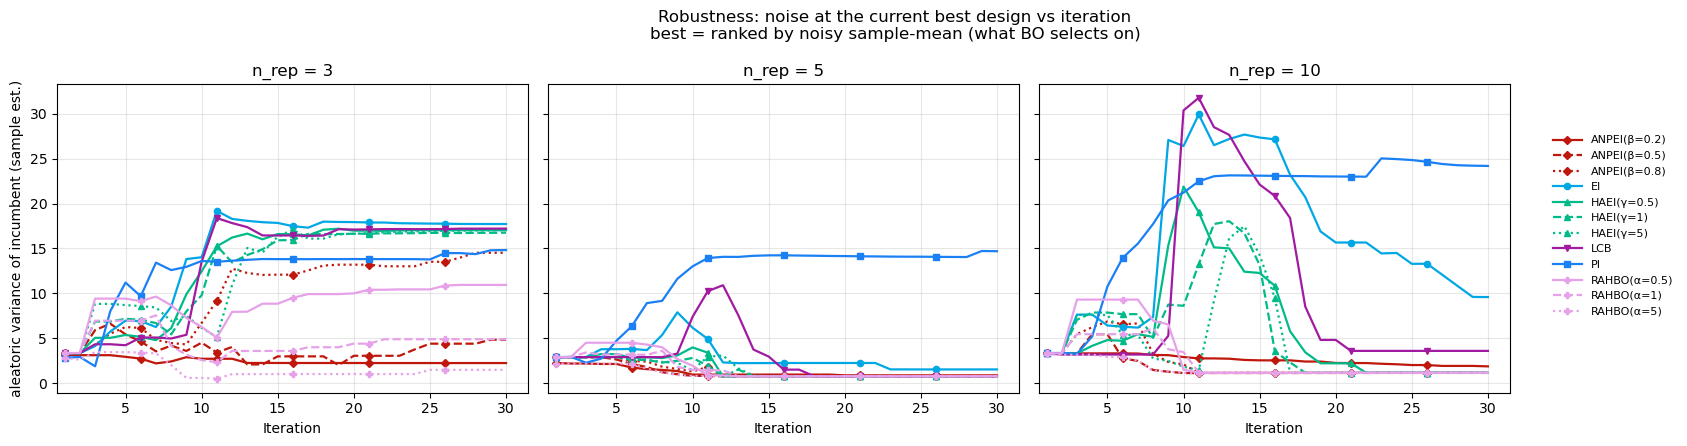

In [23]:
study.plot_incumbent_variance(is_ground_truth=False)


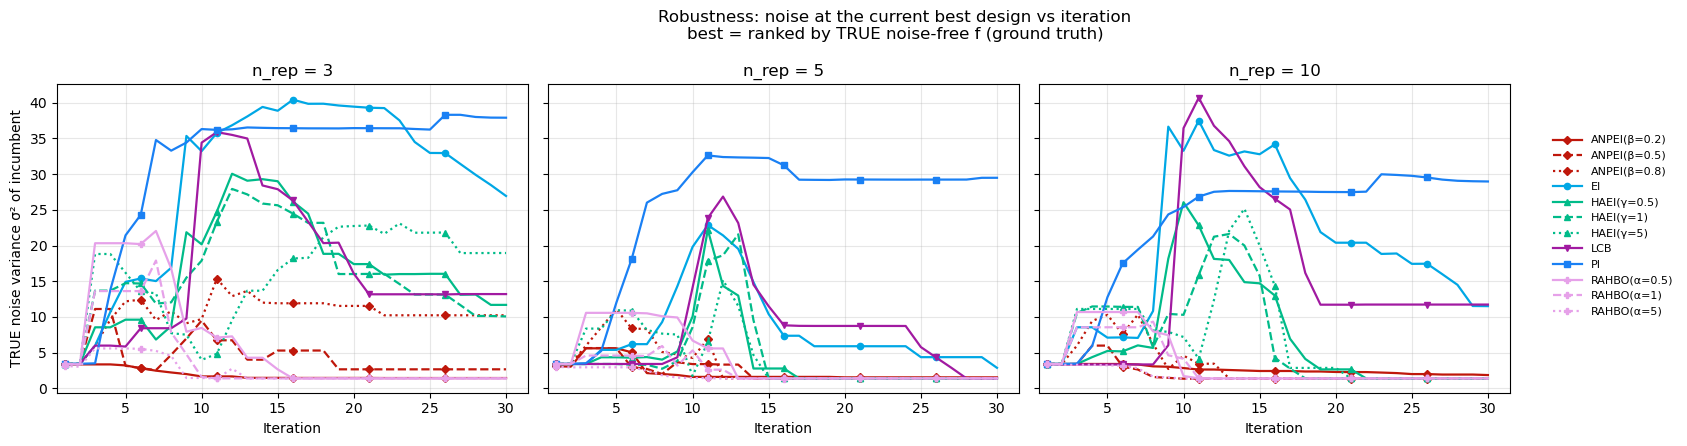

In [41]:
study.plot_incumbent_variance(is_ground_truth=True)


### 4c-table. Incumbent-noise summary (per config × n_rep)

Condenses the curves above. **Key:** the target is the **optimum's own noise** σ²_opt ≈ **1.41**
(the true optimum sits in a noisy region), **not 0** — so a converged incumbent settles *at*
1.41; a value well above means it's stuck in a noisier off-optimum region. Per config, over 30 seeds:

- **final** — mean incumbent σ² at the last iteration (where it settles; target ≈ 1.41),
- **median** — robust settle point (`final ≫ median` = a few tail seeds stuck high; `median` high = *most* seeds stuck),
- **peak** — mean of each seed's **worst** incumbent σ² (mid-run excursion into noisy regions; **low peak = risk-averse**),
- **conv%** — % of seeds settling within ±15% of σ²_opt (homed in on the *true* optimum's noise).

Conclusion-ready reads: (1) **RAHBO(α=5) peak ≈ 3–7 vs others 30–60** — strong risk-aversion keeps
the incumbent out of noisy extremes the whole run; (2) **conv%** is 100% for RAHBO/HAEI at n_rep≥5 but
**0–7% for PI**; (3) no method settles *below* 1.41 → risk-aversion didn't trade the noisy optimum for a
quiet-but-wrong corner; (4) `final ≫ median` (e.g. LCB n_rep=3) = the tail-seed story again.
Saved to `plots/analysis/incumbent_variance_table.xlsx`.


In [25]:
# incumbent-noise table (TRUE σ², ±15% conv band), write styled Excel, show inline
inc_tbl = study.incumbent_variance_table(is_ground_truth=True, tol=0.15,
                                         excel_path='plots/analysis/incumbent_variance_table.xlsx')
inc_tbl.style.format(precision=3, na_rep='—') \
    .background_gradient(cmap='RdYlGn_r', subset=[(f'n_rep={nr}', m)
        for nr in study.n_reps for m in ('final', 'median', 'peak')])


wrote plots/analysis/incumbent_variance_table.xlsx


## 5. Best designs


### 5a. Best design per seed — selection NOISY then TRUE


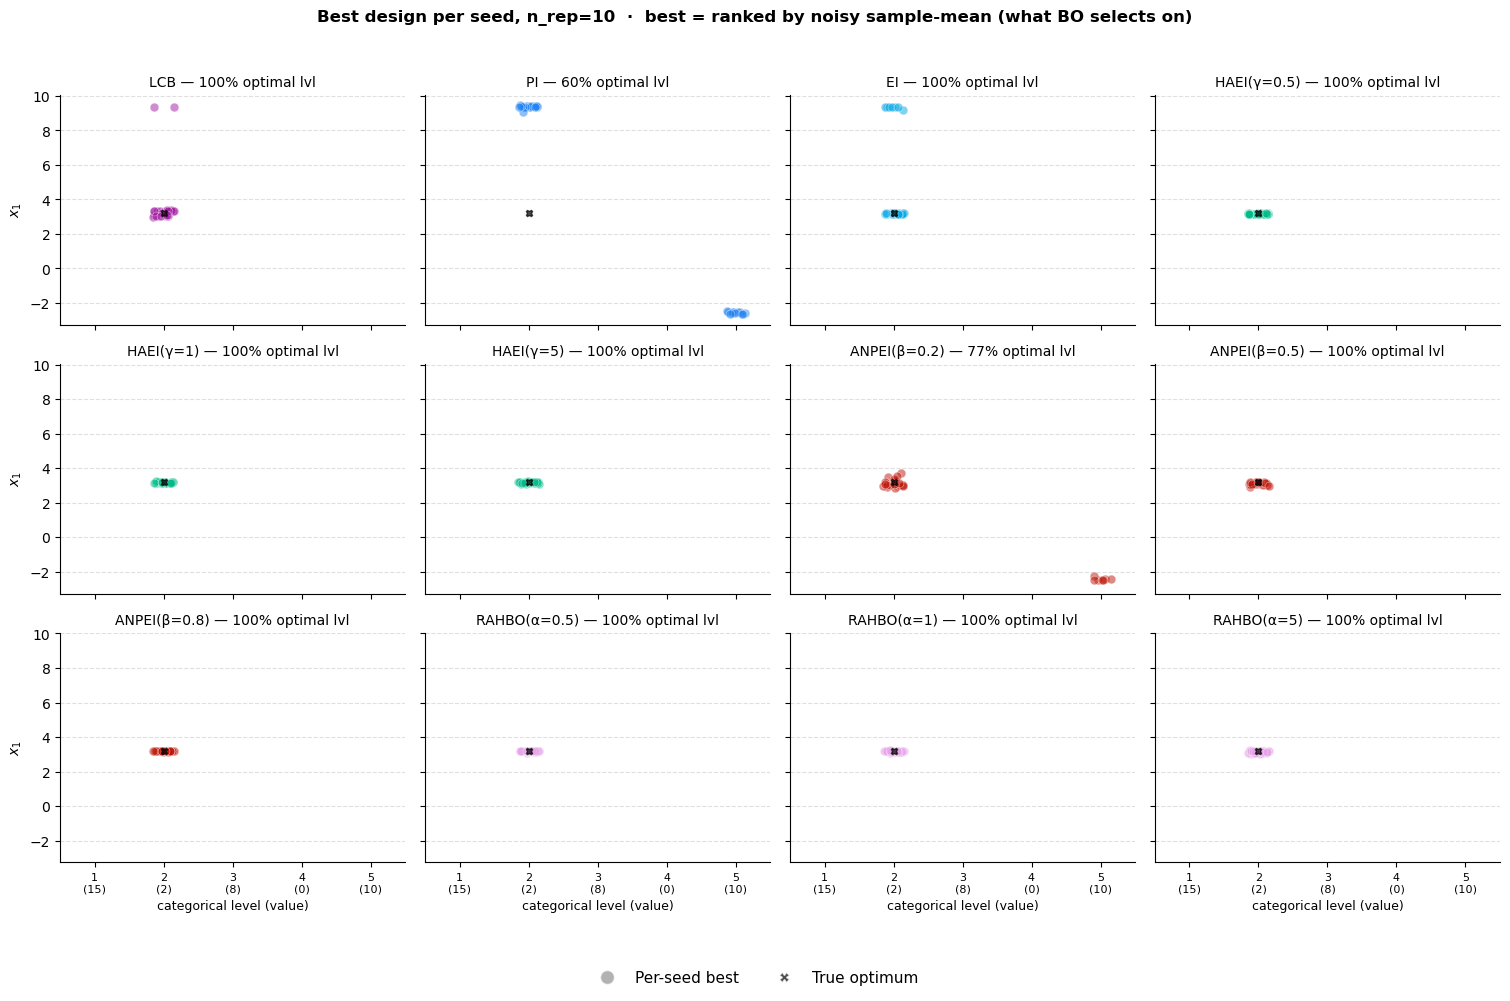

In [26]:
study.plot_best_designs(n_rep=10, is_ground_truth=False)   # design BO reported (noisy)


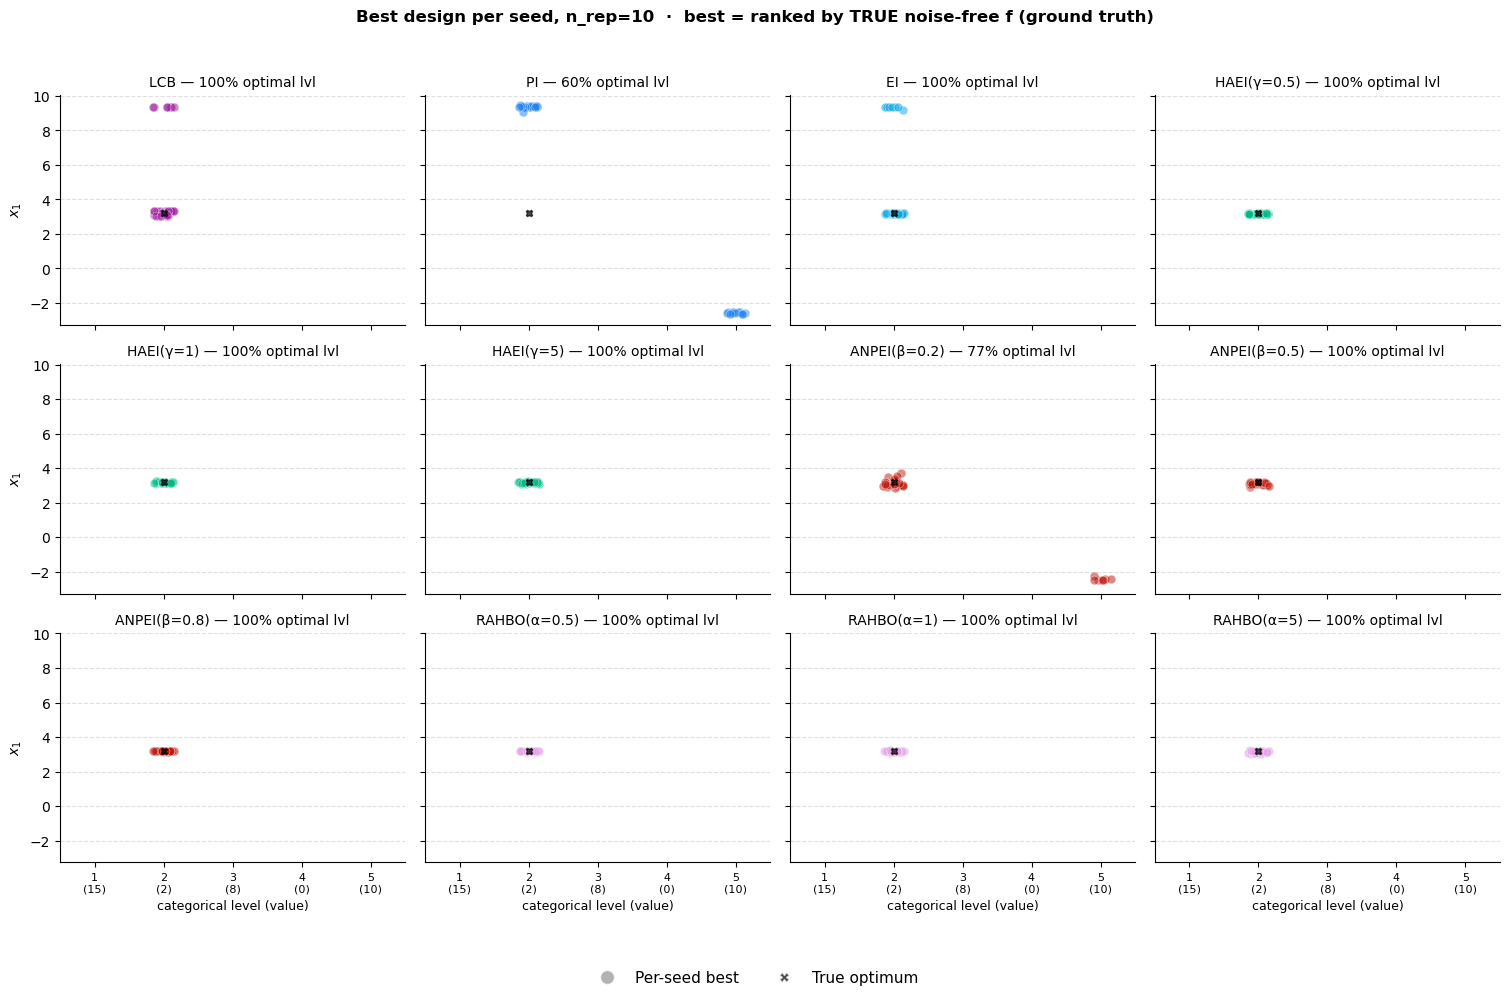

In [27]:
study.plot_best_designs(n_rep=10, is_ground_truth=True)    # truly-best sampled design


### 5b. Best objective within each category — **NOISY** then **TRUE**


In [28]:
# study.plot_best_per_category(n_rep=10, is_ground_truth=False)


In [29]:
# study.plot_best_per_category(n_rep=10, is_ground_truth=True)


### 5c. Final-objective boxplots — **NOISY** then **TRUE**


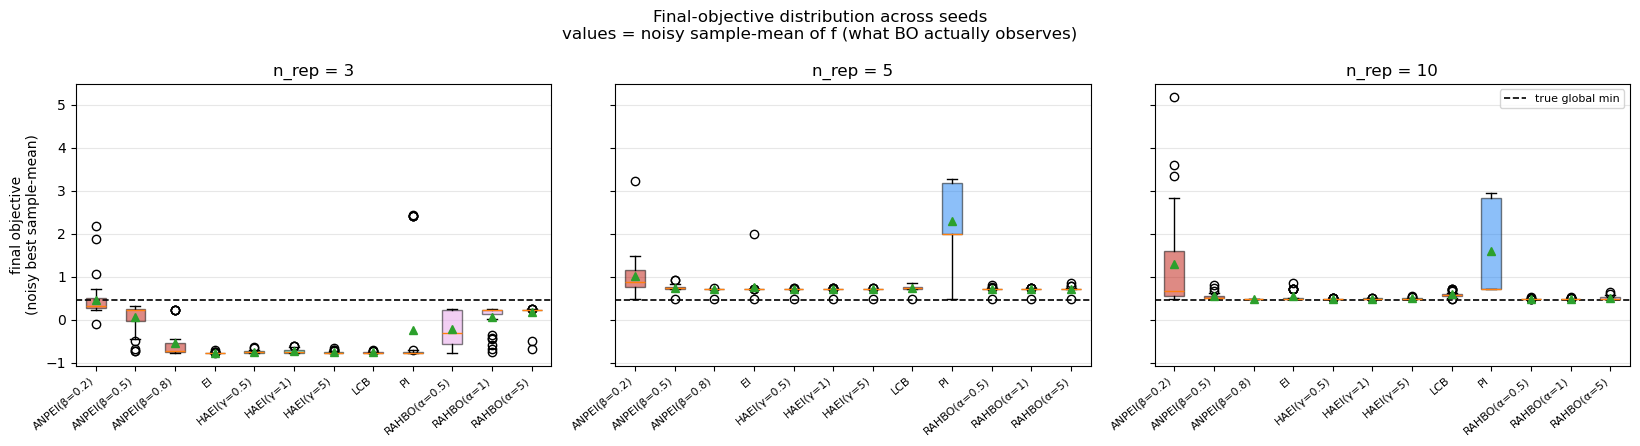

In [30]:
study.plot_final_boxplots(is_ground_truth=False)


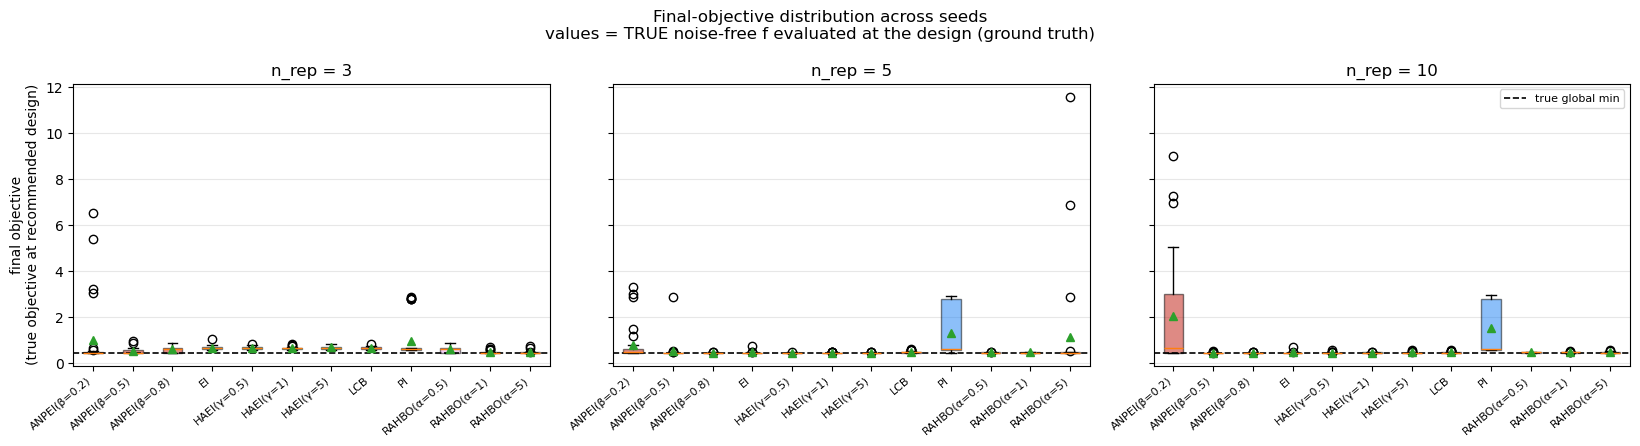

In [31]:
study.plot_final_boxplots(is_ground_truth=True)


## 6. Budget / cost summaries


### 6a. Sensitivity to n_rep — **NOISY** then **TRUE**


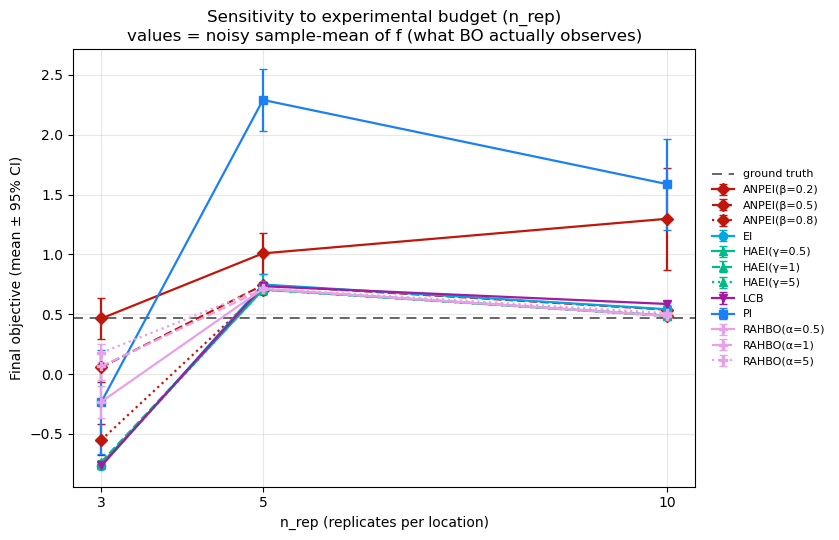

In [32]:
study.plot_nrep_sensitivity(is_ground_truth=False)


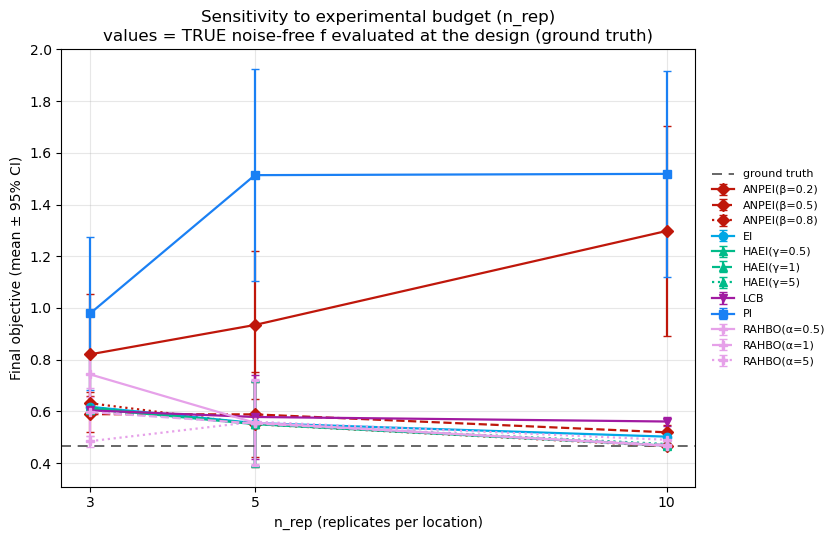

In [33]:
study.plot_nrep_sensitivity(is_ground_truth=True)


### 6b. Grid summary heatmaps — **NOISY** then **TRUE**
`log=True` uses a log colour scale (applied per panel where values are positive — great for the
wide-ranging variance panel). `obj_cmap=` / `var_cmap=` pick each panel's colormap
(any Matplotlib name, e.g. `viridis_r`, `cividis`, `inferno`, `magma_r`).


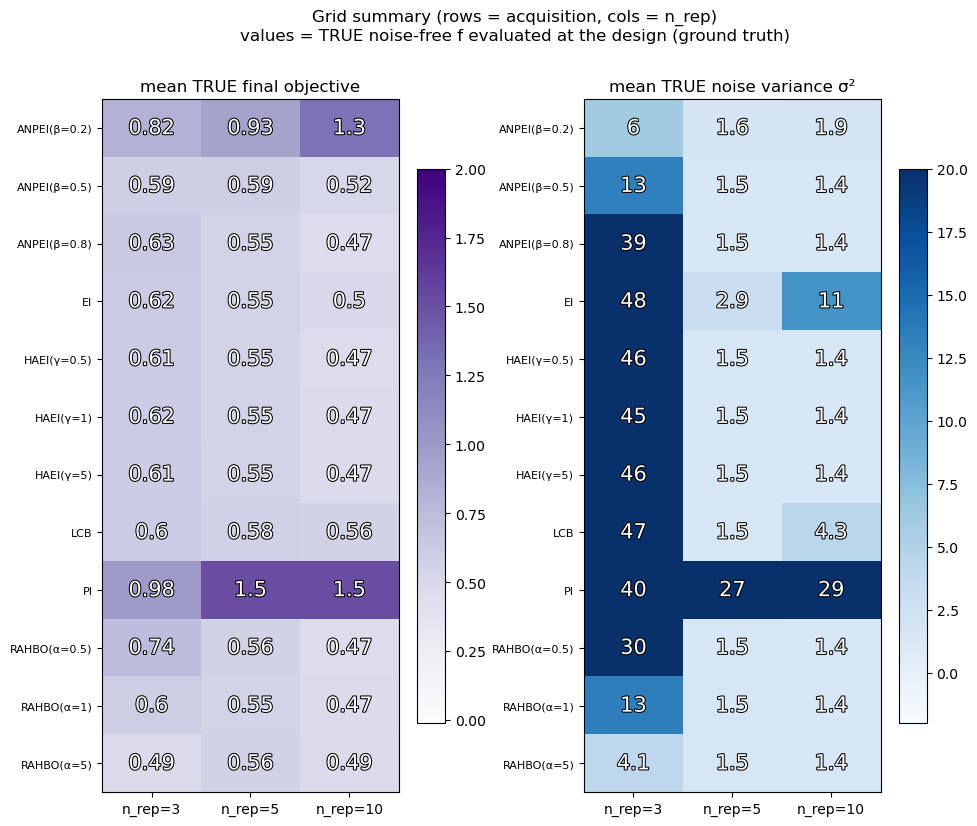

In [40]:
study.plot_summary_heatmaps(is_ground_truth=True, log=False, obj_cmap="Purples", var_cmap="Blues", obj_vmin=-.01, obj_vmax=2, var_vmin=-2, var_vmax=20, txtwidth=1.5, fontsize=15, wspace=.3)


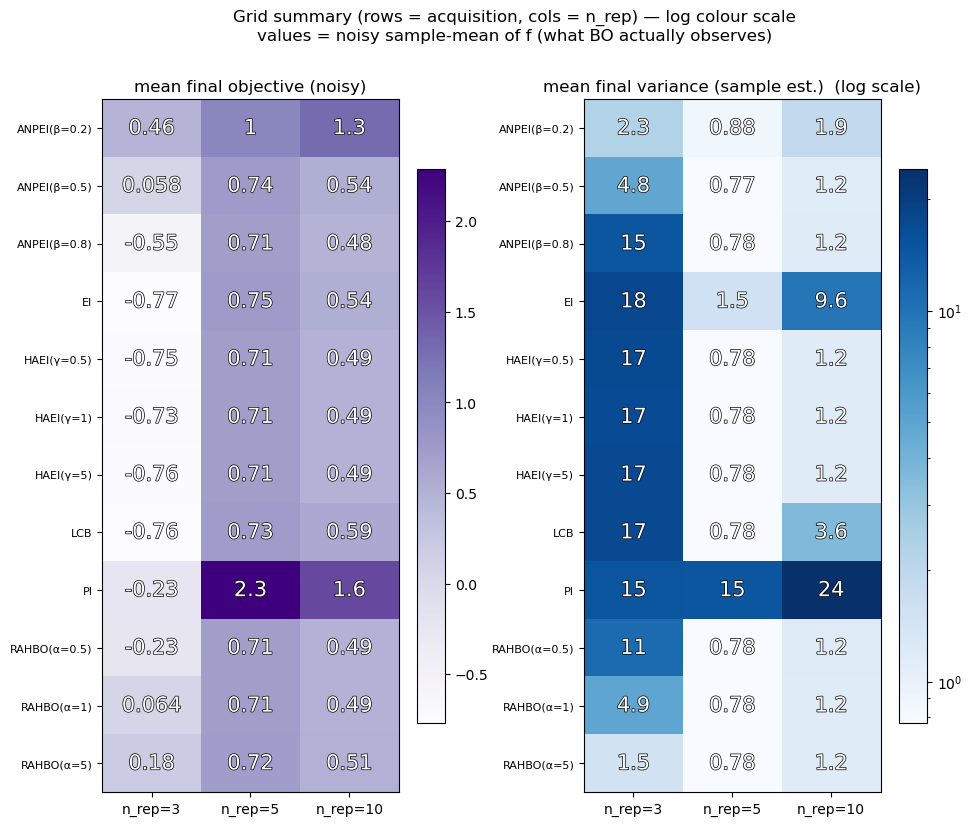

In [35]:
study.plot_summary_heatmaps(is_ground_truth=False, log=True, obj_cmap='Purples', var_cmap='Blues')


### 6c. Runtime per acquisition — *cost only*


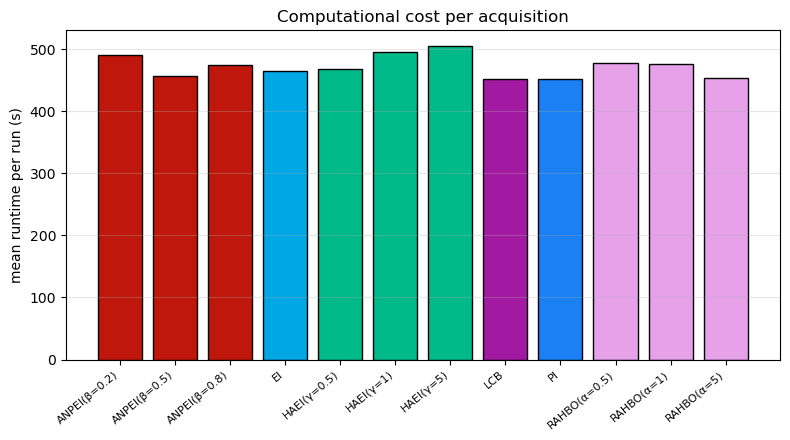

In [36]:
study.plot_runtime()


## 7. Single run — per-category slices
Shows the true f curve + noise band + the noisy samples on it (both sources visible).


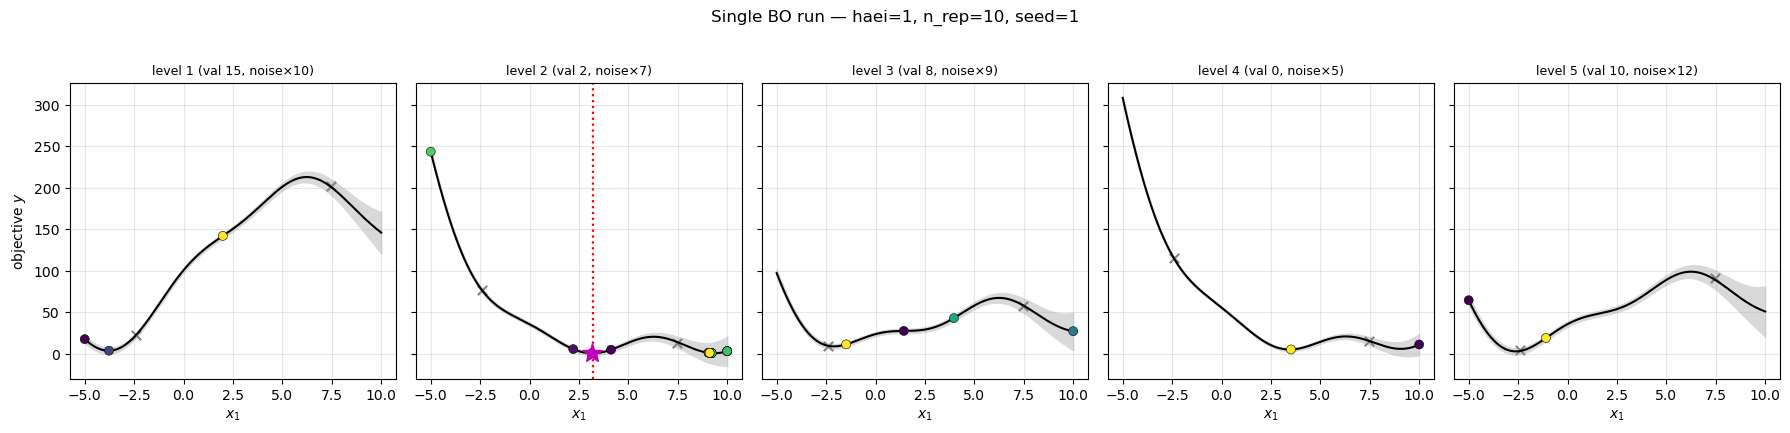

In [37]:
study.plot_single_run('haei_g1/nrep10/seed01.mat')


## (optional) save every plot to the plots/ tree


In [38]:
import save_all_plots; importlib.reload(save_all_plots); save_all_plots.main()


loaded 1080 runs
plots/main:
  saved plots/main/0_progress.png
  saved plots/main/0b_initial_doe.png
  saved plots/main/1_convergence_noisy.png
  saved plots/main/1b_convergence_true_log.png
  saved plots/main/1b_convergence_true_zoom.png
  saved plots/main/1c_x1_convergence_noisy.png
  saved plots/main/1c_x1_convergence_true.png
  saved plots/main/1d_x1_distribution_noisy.png
  saved plots/main/1d_x1_distribution_true.png
  saved plots/main/1e_x1_landing.png
  saved plots/main/2_input_space.png
  saved plots/main/2b_best_designs_noisy.png
  saved plots/main/2b_best_designs_true.png
  saved plots/main/3_level_histogram.png
  saved plots/main/4_objective_variance_noisy.png
  saved plots/main/4_objective_variance_true.png
  saved plots/main/5_final_boxplots_noisy.png
  saved plots/main/5_final_boxplots_true.png
  saved plots/main/6_best_per_category_noisy.png
  saved plots/main/6_best_per_category_true.png
plots/analysis:
  saved plots/analysis/A_simple_regret_noisy.png
  saved plots/ana